# Data Preparation

## Import Libraries

In [1]:
# Untuk manipulasi data
import pandas as pd
import numpy as np

# Untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk preprocessing & modelling klasik (sklearn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Untuk modelling Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


## Load Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/melbourne-housing-snapshot


In [3]:
import pandas as pd
import os

csv_file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(csv_file_path)

print(df.head())

       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionname  \
0     

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [5]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 13580
Jumlah kolom: 21


## Data Cleaning and Type Conversion

In [6]:
# Konversi 'Date' menjadi datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [7]:
print("Missing values sebelum ditangani:\n", df.isnull().sum())

Missing values sebelum ditangani:
 Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date             8442
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


# Handle Missing Value

In [8]:
# Drop baris yang harga (Price)-nya kosong (harus ada karena target)
df.dropna(subset=['Price'], inplace=True)

# Kolom penting: isi NaN dengan median
for col in ['Car', 'BuildingArea']:
    df[col].fillna(df[col].median(), inplace=True)

# Setelah pengisian, drop sisanya yang masih NaN (contoh: Date yang gagal parsing)
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

# Cek ulang
print("Missing values setelah dibersihkan:\n", df.isnull().sum())


Missing values setelah dibersihkan:
 Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


<ipython-input-8-40f6f1e50247>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [9]:
# Tipe data kolom numerik
num_cols = ['Rooms', 'Price', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Lattitude', 'Longtitude', 'Propertycount']
df[num_cols] = df[num_cols].astype(float)

# Cek tipe data terakhir
print(df.dtypes)

Suburb                   object
Address                  object
Rooms                   float64
Type                     object
Price                   float64
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                float64
Bedroom2                float64
Bathroom                float64
Car                     float64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea              object
Lattitude               float64
Longtitude              float64
Regionname               object
Propertycount           float64
dtype: object


## Handle Duplicate Data

In [10]:
# Cek jumlah baris sebelum menghapus duplikat
before = df.shape[0]

# Cek apakah ada baris yang duplikat secara keseluruhan
duplicates = df.duplicated().sum()
print(f" Jumlah baris duplikat: {duplicates}")

 Jumlah baris duplikat: 0


In [11]:
# Hapus duplikat
df.drop_duplicates(inplace=True)

# Cek jumlah baris setelah penghapusan
after = df.shape[0]
print(f" Jumlah baris dihapus: {before - after}")
print(f" Total baris sekarang: {after}")

 Jumlah baris dihapus: 0
 Total baris sekarang: 2953


In [12]:
# Cek duplikat berdasarkan subset kolom penting
df.duplicated(subset=['Suburb', 'Rooms', 'Price', 'Distance', 'Landsize']).sum()

np.int64(5)

In [13]:
df.drop_duplicates(subset=['Suburb', 'Rooms', 'Price', 'Distance', 'Landsize'], inplace=True)

In [14]:
df.reset_index(drop=True, inplace=True)


## Sort Data and Set Index

In [15]:
# Sort berdasarkan Price secara ascending (dari yang termurah ke termahal)
df.sort_values(by='Price', ascending=True, inplace=True)

# Reset index agar rapi setelah sorting
df.reset_index(drop=True, inplace=True)

# Cek 5 data teratas untuk verifikasi
print(df.head())

      Suburb           Address  Rooms Type     Price Method  SellerG  \
0  Footscray  202/51 Gordon St    1.0    u   85000.0     PI  Burnham   
1     Coburg   171 Moreland Rd    4.0    h  145000.0     PI   Jellis   
2   Hawthorn     17/17 Park St    1.0    u  160000.0     VB      HAR   
3  Footscray  10/30 Pickett St    1.0    u  170000.0     PI  Burnham   
4  Footscray   2/3 Eldridge St    1.0    u  216000.0      S  Sweeney   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0 2016-03-09       6.4    3011.0  ...       1.0  0.0       0.0         126.0   
1 2016-04-06       7.8    3058.0  ...       1.0  1.0     536.0         164.0   
2 2017-08-04       4.6    3122.0  ...       1.0  0.0     322.0         126.0   
3 2017-01-07       5.1    3011.0  ...       1.0  0.0      30.0          26.0   
4 2016-04-02       6.4    3011.0  ...       1.0  1.0       0.0          50.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionname  \
0     2007.0

# Exploratory Data Analysis

## Summary

count    2.948000e+03
mean     1.060376e+06
std      6.654903e+05
min      8.500000e+04
25%      6.100000e+05
50%      8.635000e+05
75%      1.320000e+06
max      5.800000e+06
Name: Price, dtype: float64


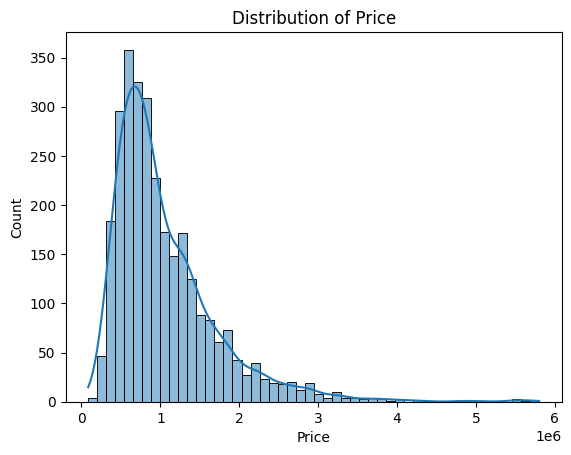

In [16]:
print(df['Price'].describe())
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.show()

## Analyze Numeric Features vs Price

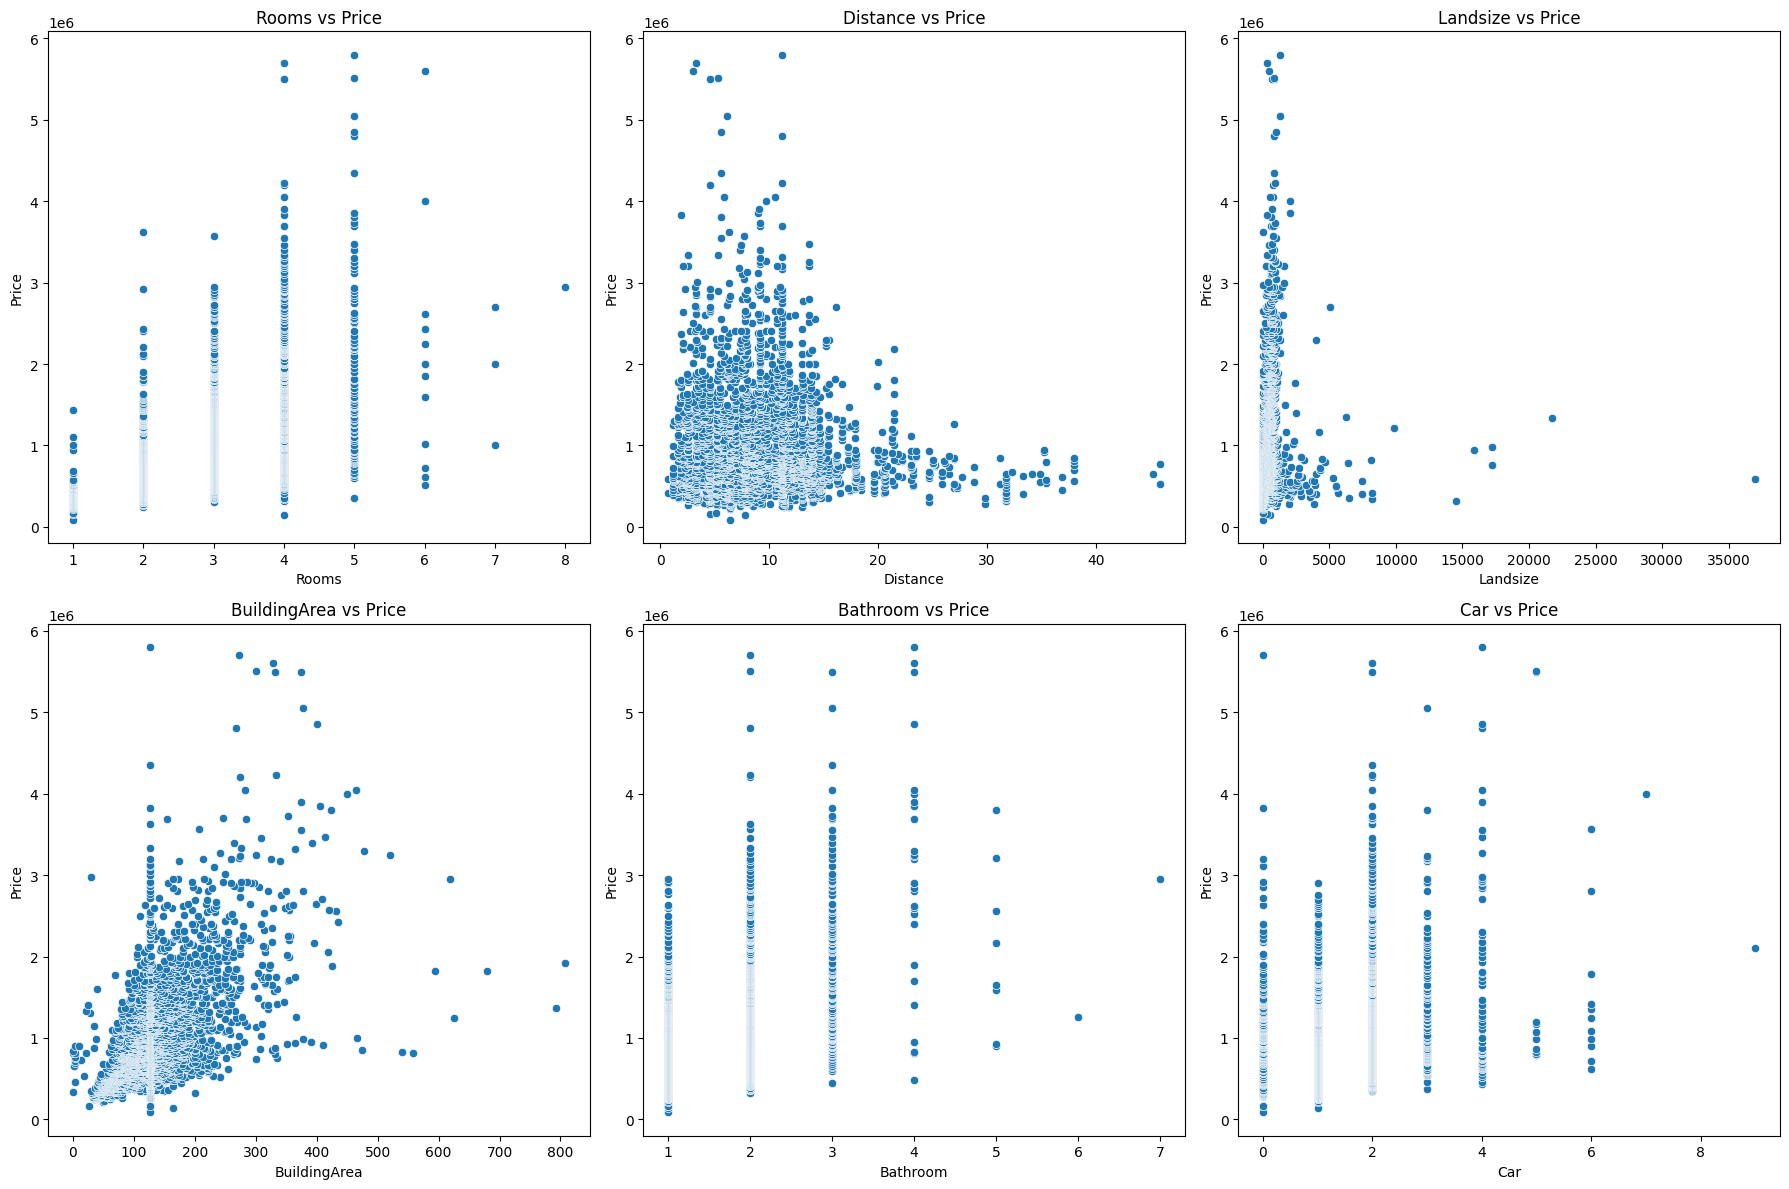

In [17]:
num_features = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'Bathroom', 'Car']

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 grid to a 1D array for easy iteration

for i, col in enumerate(num_features):
    sns.scatterplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

# Remove any unused subplots if the number of features is less than the total number of plots
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent titles/labels overlapping
plt.show()

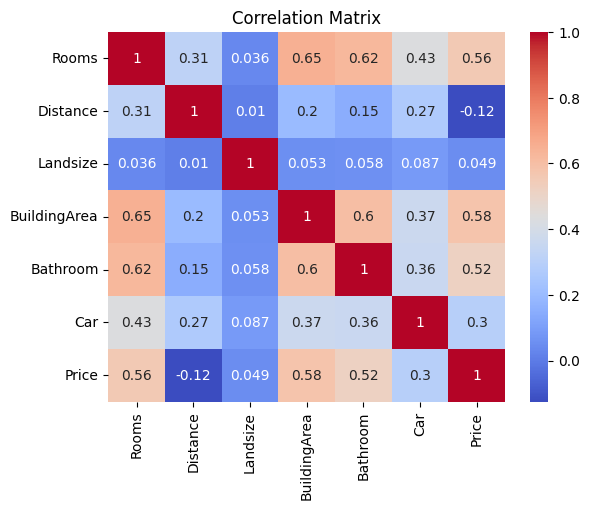

In [18]:
corr = df[num_features + ['Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Korelasi Mayoritas Positif: Sebagian besar fitur (Rooms, Landsize, BuildingArea, Bathroom, Car) menunjukkan korelasi positif dengan Price. Ini berarti, secara umum, semakin tinggi nilai fitur-fitur ini, semakin tinggi pula harga properti.
Korelasi Negatif untuk Jarak: Fitur Distance menunjukkan korelasi negatif dengan Price, yang berarti semakin jauh jarak properti, harganya cenderung lebih rendah.
Variabilitas Harga yang Tinggi: Untuk hampir semua fitur, terutama di nilai-nilai yang umum (misalnya 2-4 kamar, Landsize/BuildingArea kecil, 1-2 Car), terdapat variabilitas harga yang sangat tinggi. Ini mengindikasikan bahwa fitur tunggal tidak cukup untuk menjelaskan semua variasi harga. Harga properti dipengaruhi oleh kombinasi banyak faktor.
Konsentrasi Data: Sebagian besar data terkonsentrasi pada nilai-nilai fitur yang lebih umum (misalnya, Rooms 2-4, Distance dekat, Landsize/BuildingArea kecil, Bathroom 1-4, Car 1-2).
Potensi Outlier dan Data Sparsity:
Ada beberapa nilai ekstrem (Landsize/BuildingArea sangat besar, Distance sangat jauh) atau jumlah fitur yang sangat tinggi (Rooms, Bathroom, Car yang tinggi) yang hanya memiliki sedikit titik data (data sparsity).
Beberapa titik data terlihat seperti outlier (misalnya, properti dengan banyak kamar mandi tetapi harga rendah, atau properti yang sangat jauh tetapi harga tinggi). Ini perlu penyelidikan lebih lanjut, apakah itu data yang valid tetapi tidak biasa, atau kesalahan entri.

## Analyze Categorical Features vs Price

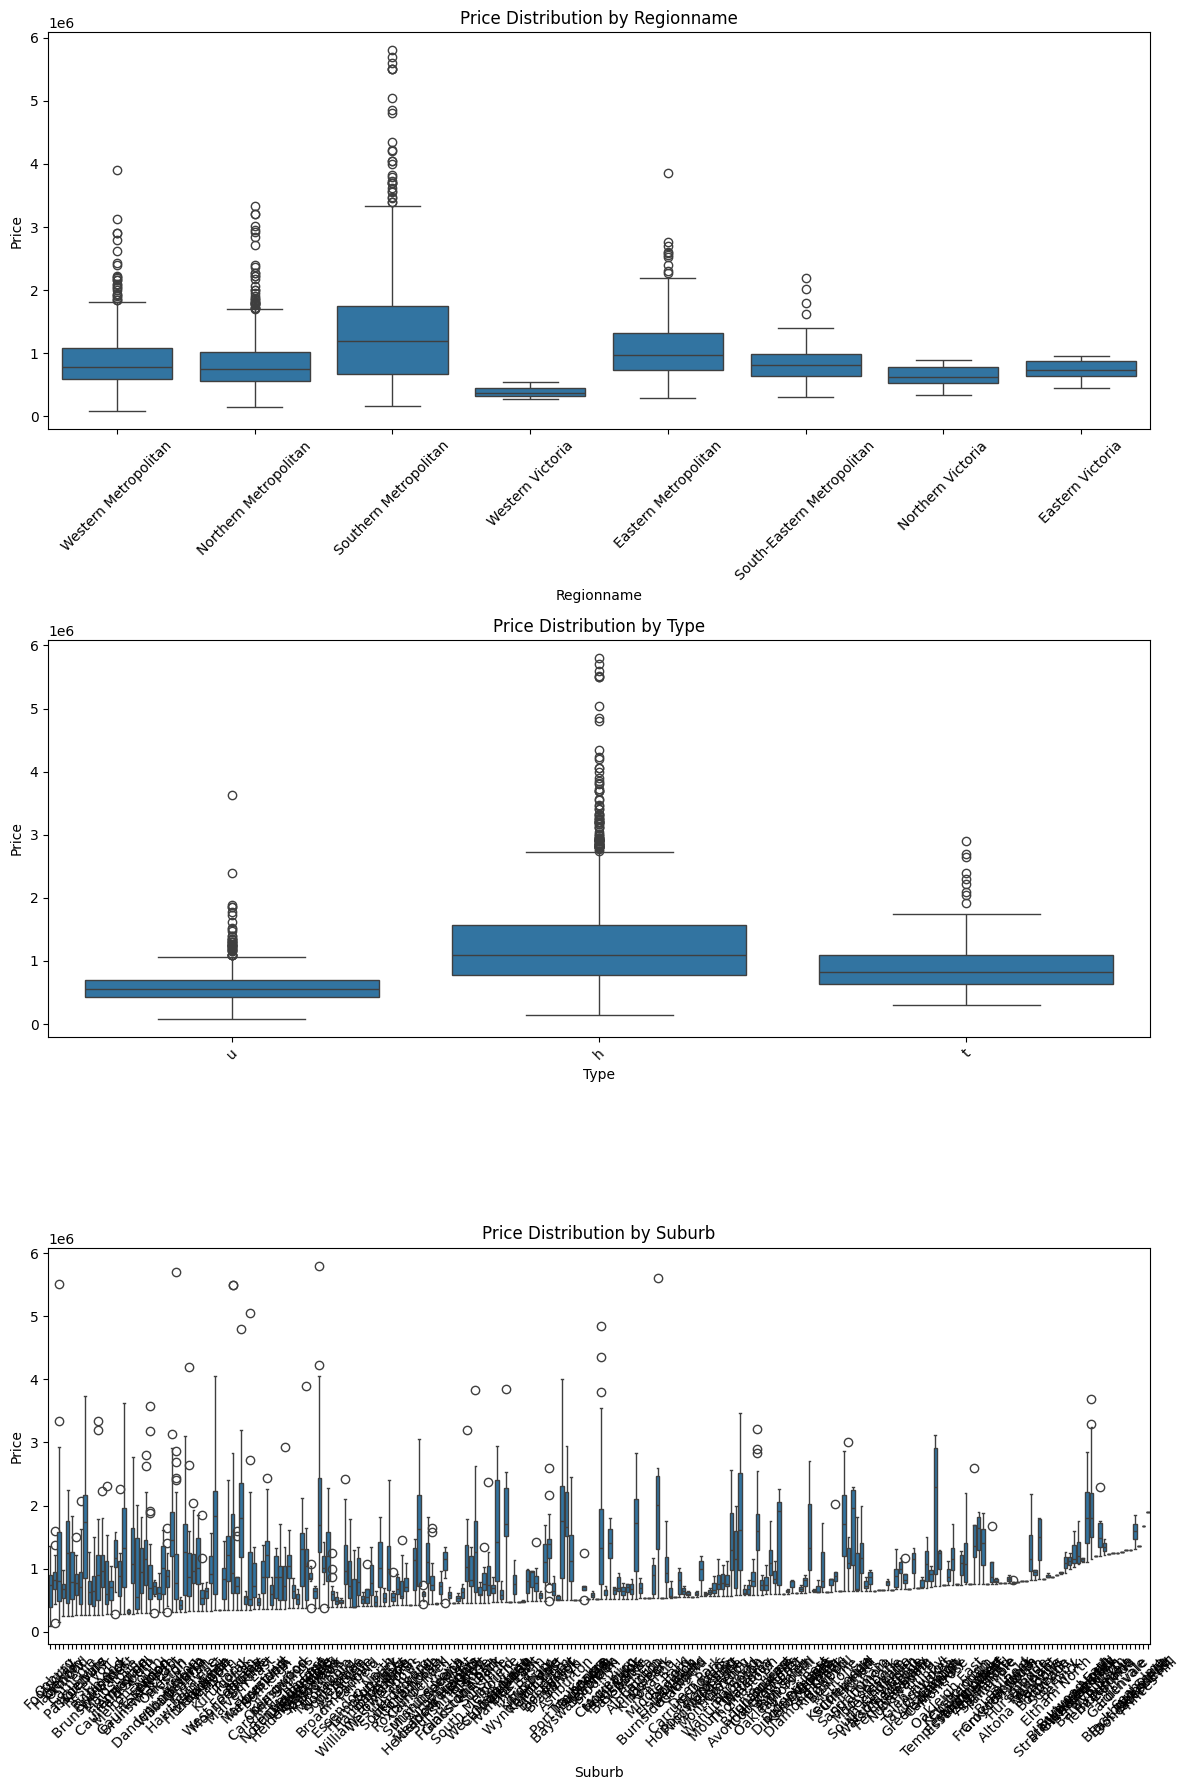

In [19]:
cat_features = ['Regionname', 'Type', 'Suburb']

# Determine the number of rows and columns for the subplot grid
n_features = len(cat_features)
n_cols = 1 # You want them stacked in one column
n_rows = n_features # The number of rows equals the number of features

# Create a figure and a set of subplots
# Adjust the figure size to accommodate stacked plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 6)) # Adjust height multiplier as needed

# Flatten the axes array if there's more than one subplot
if n_features > 1:
    axes = axes.flatten()
else: # If only one subplot, axes is not an array
    axes = [axes] # Make it a list so the loop works

for i, col in enumerate(cat_features):
    sns.boxplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'Price Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels

plt.tight_layout() # Adjust layout to prevent titles/labels overlapping
plt.show()

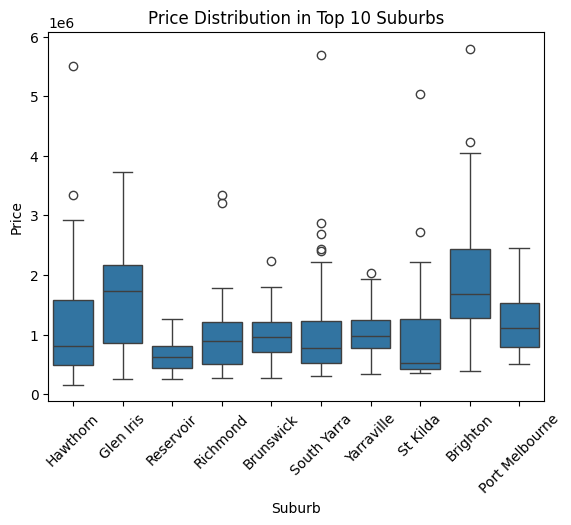

In [20]:
top_suburbs = df['Suburb'].value_counts().nlargest(10).index
sns.boxplot(x=df[df['Suburb'].isin(top_suburbs)]['Suburb'], y=df['Price'])
plt.title('Price Distribution in Top 10 Suburbs')
plt.xticks(rotation=45)
plt.show()

Lokasi Adalah Raja: Ketiga plot ini secara konsisten menunjukkan bahwa lokasi (Regionname, Suburb) memiliki dampak yang sangat besar dan menjadi faktor paling dominan dalam menentukan harga properti. Bahkan dalam satu wilayah (Regionname), ada variasi harga yang signifikan antar Suburb.
Tipe Properti Memiliki Peran Penting: Selain lokasi, Type properti juga merupakan faktor penting yang membedakan harga secara substansial, dengan rumah tapak (h) secara umum lebih mahal.
Adanya Properti Mewah: Kehadiran outlier dengan harga sangat tinggi di kategori-kategori tertentu (terutama Southern Metropolitan, Eastern Metropolitan, tipe 'h', dan beberapa suburb spesifik) menunjukkan adanya segmen pasar properti mewah.
Kebutuhan Data Granular: Untuk prediksi harga yang akurat, model harus memperhitungkan variabel kategori ini, terutama Suburb, meskipun memerlukan penanganan khusus karena jumlah kategorinya yang banyak.

# Feature Engineering

In [21]:
import pandas as pd

selected_features = [
    'Distance',
    'Propertycount',
    'Rooms',
    'Bathroom',
    'Car',
    'Landsize',
    'BuildingArea'
]

df_feature = df[selected_features].copy()

# Isi missing values dengan median
for col in selected_features:
    df_feature[col].fillna(df_feature[col].median(), inplace=True)

# Tambahan fitur rasio bangunan terhadap tanah
df_feature['Building_to_Land_Ratio'] = df_feature['BuildingArea'] / (df_feature['Landsize'] + 1)

# Target
y = df['Price']
X = df_feature

<ipython-input-21-858c7cd68b71>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_feature[col].fillna(df_feature[col].median(), inplace=True)


# Data Preprocessing

## Feature Selection

## Data Splitting

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelling

## Modelling 1

In [24]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)


=== Linear Regression Evaluation ===
MAE: 318367.21
RMSE: 488189.56
R^2: 0.46
MAPE: 0.33%


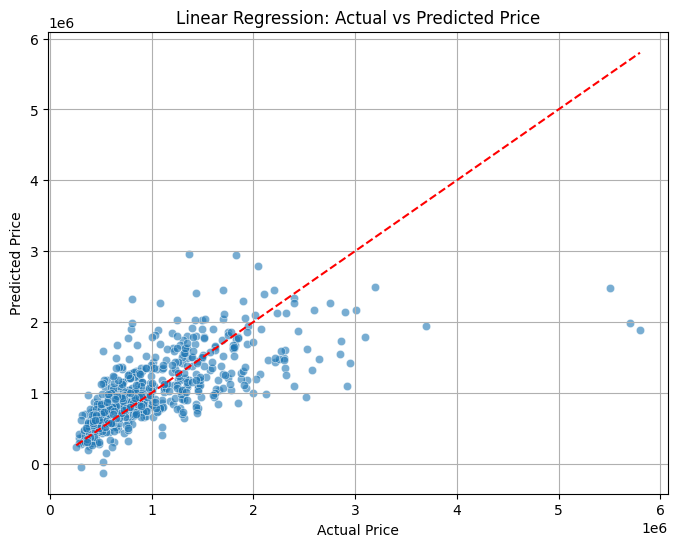

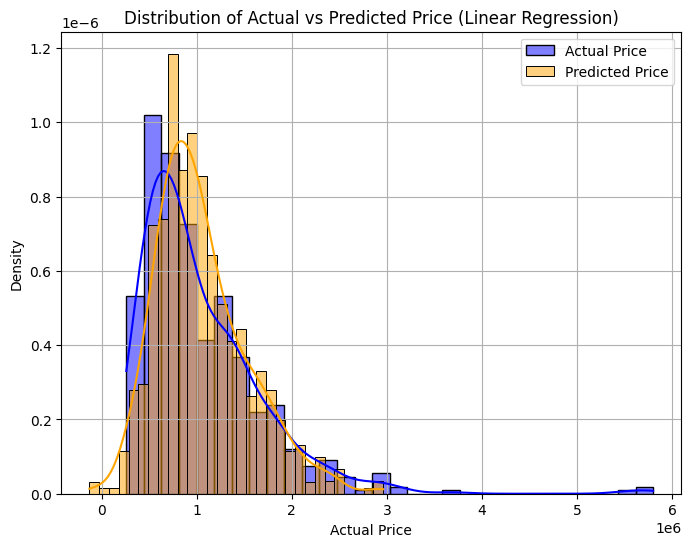

In [25]:
# Evaluation Metrics
print("\n=== Linear Regression Evaluation ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lr) ** 0.5:.2f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_lr):.2f}%")

# Visualisasi Prediksi vs Aktual (scatter)
df_lr_compare = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred_lr}).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=df_lr_compare, alpha=0.6)
plt.plot([df_lr_compare['Actual Price'].min(), df_lr_compare['Actual Price'].max()],
         [df_lr_compare['Actual Price'].min(), df_lr_compare['Actual Price'].max()], 'r--')
plt.title("Linear Regression: Actual vs Predicted Price")
plt.grid(True)
plt.show()

# Visualisasi Distribusi
plt.figure(figsize=(8,6))
sns.histplot(df_lr_compare['Actual Price'], color='blue', label='Actual Price', kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(df_lr_compare['Predicted Price'], color='orange', label='Predicted Price', kde=True, stat="density", bins=30, alpha=0.5)
plt.title('Distribution of Actual vs Predicted Price (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()


## Modelling 2

In [26]:
model_dnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_dnn.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Training
history = model_dnn.fit(X_train_scaled, y_train, validation_split=0.1,
                        epochs=100, batch_size=32, verbose=0)

# Predict
y_pred_dnn = model_dnn.predict(X_test_scaled).flatten()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step



=== Deep Learning Evaluation ===
MAE: 310192.72
RMSE: 477531.83
R^2: 0.48
MAPE: 0.30%


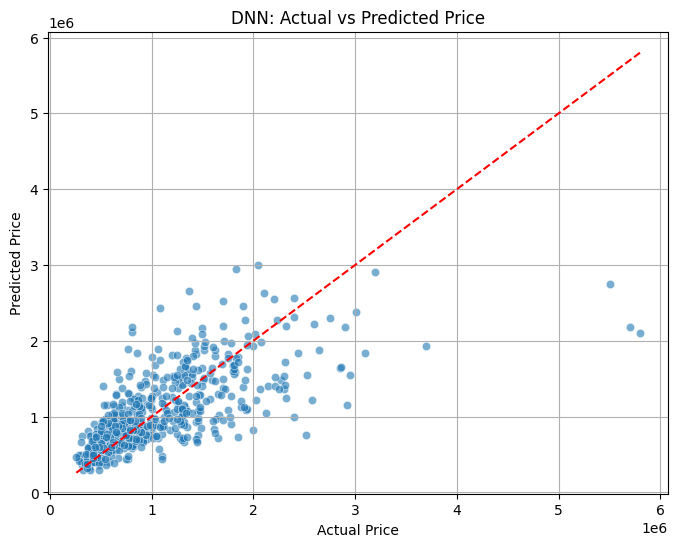

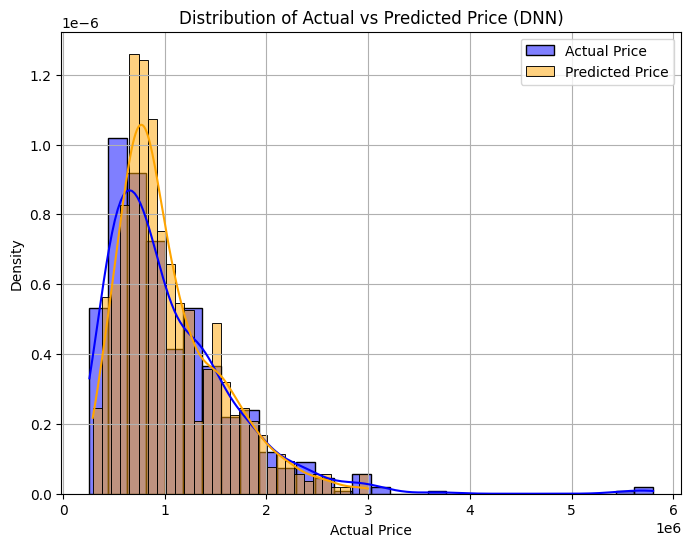

In [27]:
# Evaluation Metrics
print("\n=== Deep Learning Evaluation ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dnn):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_dnn) ** 0.5:.2f}")
print(f"R^2: {r2_score(y_test, y_pred_dnn):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_dnn):.2f}%")

# Visualisasi Prediksi vs Aktual (scatter)
df_dnn_compare = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred_dnn}).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=df_dnn_compare, alpha=0.6)
plt.plot([df_dnn_compare['Actual Price'].min(), df_dnn_compare['Actual Price'].max()],
         [df_dnn_compare['Actual Price'].min(), df_dnn_compare['Actual Price'].max()], 'r--')
plt.title("DNN: Actual vs Predicted Price")
plt.grid(True)
plt.show()

# Visualisasi Distribusi
plt.figure(figsize=(8,6))
sns.histplot(df_dnn_compare['Actual Price'], color='blue', label='Actual Price', kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(df_dnn_compare['Predicted Price'], color='orange', label='Predicted Price', kde=True, stat="density", bins=30, alpha=0.5)
plt.title('Distribution of Actual vs Predicted Price (DNN)')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation

In [28]:
def evaluate_model(y_true, y_pred, label='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"Evaluasi {label}:")
    print(f"  MAE : {mae:.2f}")
    print(f"  MSE : {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²  : {r2:.4f}")
    print(f"  MAPE: {mape:.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dnn, "Deep Learning")

Evaluasi Linear Regression:
  MAE : 318367.21
  MSE : 238329050760.70
  RMSE: 488189.56
  R²  : 0.4566
  MAPE: 0.3253
Evaluasi Deep Learning:
  MAE : 310192.72
  MSE : 228036649457.14
  RMSE: 477531.83
  R²  : 0.4800
  MAPE: 0.3048


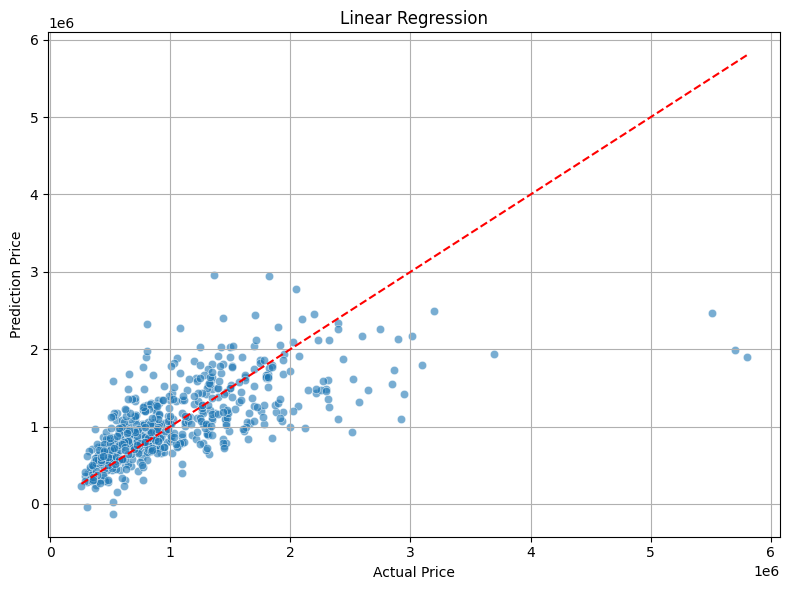

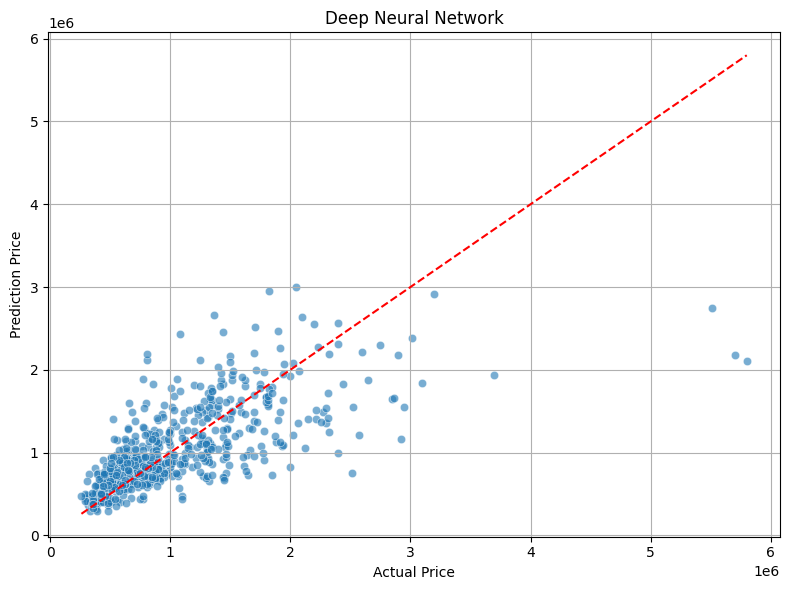

In [29]:
def plot_predictions(y_true, y_pred, title='Prediksi vs Nilai Sebenarnya'):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Price')
    plt.ylabel('Prediction Price')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred_lr, 'Linear Regression')
plot_predictions(y_test, y_pred_dnn, 'Deep Neural Network')

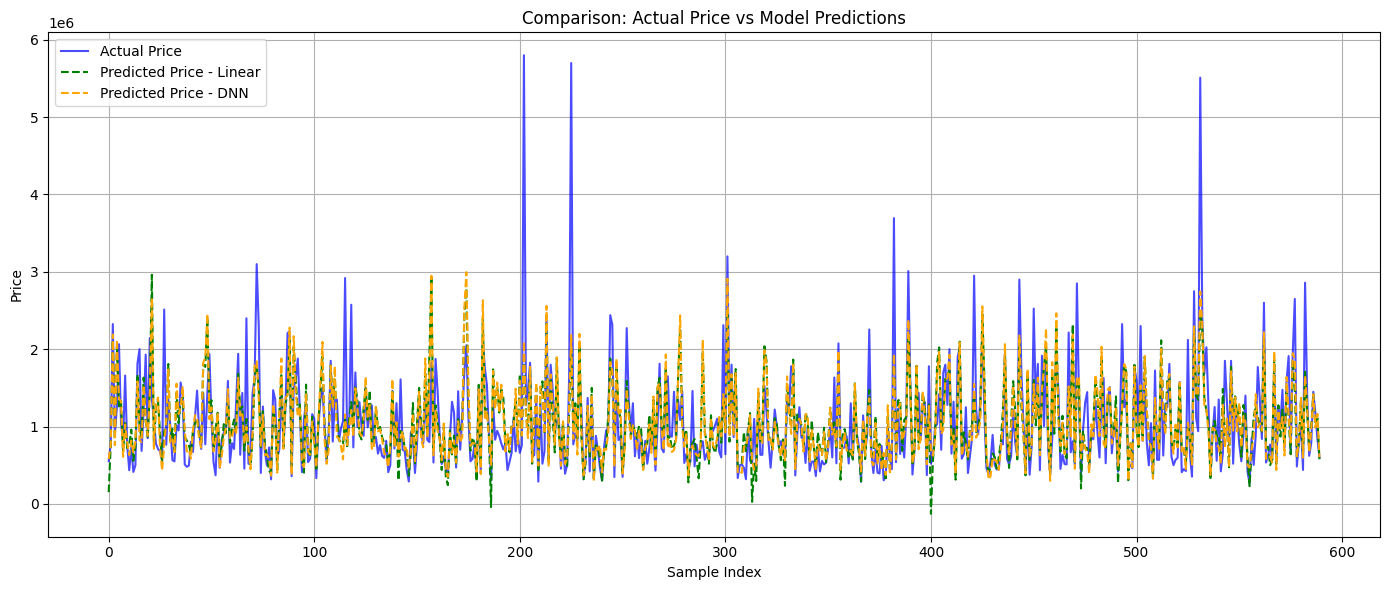

In [30]:
df_comparison = pd.DataFrame({
    'Actual Price': y_test.reset_index(drop=True),
    'Predicted Price - Linear': y_pred_lr,
    'Predicted Price - DNN': y_pred_dnn
})

plt.figure(figsize=(14,6))
plt.plot(df_comparison['Actual Price'], label='Actual Price', color='blue', alpha=0.7)
plt.plot(df_comparison['Predicted Price - Linear'], label='Predicted Price - Linear', color='green', linestyle='--')
plt.plot(df_comparison['Predicted Price - DNN'], label='Predicted Price - DNN', color='orange', linestyle='--')
plt.title('Comparison: Actual Price vs Model Predictions')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
